In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error



In [4]:
ml_data = pd.read_csv("simulationData.csv")

print("Preview of dataset:")
ml_data.head()


Preview of dataset:


,Initial_Speed,Launch_Angle,Theoretical_Range,Measured_Range
0,80.800601,64.524638,516.844670,516.584200
1,99.667520,81.019069,312.269767,311.733589
2,91.968067,64.823430,663.882355,663.359426
3,24.446647,86.528542,7.364199,7.964288
4,27.600274,60.268134,66.883055,65.359004


In [5]:
input_features = ml_data[["Initial_Speed", "Launch_Angle"]]
target_output = ml_data["Measured_Range"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    input_features,
    target_output,
    test_size=0.2,
    random_state=42
)


In [7]:
model_set = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor()
}


In [8]:
performance_records = []

for model_name, model in model_set.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    r2_val = r2_score(y_test, predictions)
    rmse_val = np.sqrt(mean_squared_error(y_test, predictions))

    performance_records.append({
        "Model": model_name,
        "R2_Score": r2_val,
        "RMSE": rmse_val
    })

results_table = pd.DataFrame(performance_records)
results_table.sort_values(by="R2_Score", ascending=False)


,Model,R2_Score,RMSE
4,Gradient Boosting,0.995954,15.458812
3,Random Forest,0.995902,15.557897
2,Decision Tree,0.988186,26.416500
1,Ridge Regression,0.733291,125.515994
0,Linear Regression,0.733291,125.516011


In [9]:
results_table.to_csv("model_results.csv", index=False)
print("model_results.csv saved successfully")


model_results.csv saved successfully


In [10]:
print("Model Comparison Results:")
results_table


Model Comparison Results:


,Model,R2_Score,RMSE
0,Linear Regression,0.733291,125.516011
1,Ridge Regression,0.733291,125.515994
2,Decision Tree,0.988186,26.416500
3,Random Forest,0.995902,15.557897
4,Gradient Boosting,0.995954,15.458812


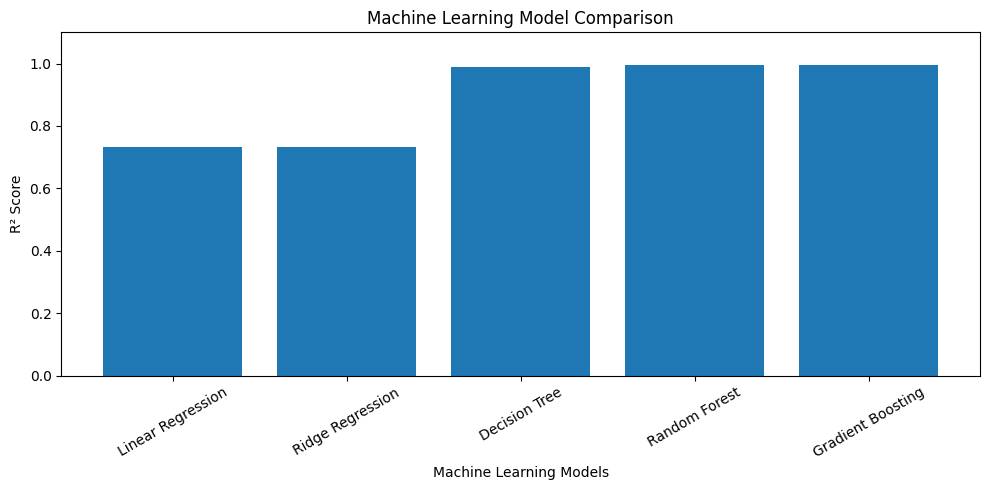

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(results_table["Model"], results_table["R2_Score"])
plt.ylim(0, 1.1)

plt.xlabel("Machine Learning Models")
plt.ylabel("R² Score")
plt.title("Machine Learning Model Comparison")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("model_comparison_graph.png")
plt.show()


In [14]:
from google.colab import files

files.download("model_results.csv")
files.download("model_comparison_graph.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>